# Classical and Neural Longstaff–Schwartz for American Put Options

## Learning continuation values from simulated risk-neutral paths

**SoftUni Deep Learning Final Project**  
**Author:** Kamen Dimitrov  
**Notebook:** `07_neural_longstaff_schwartz.ipynb`

---

The earlier notebooks learn a static American-option pricing surface from CRR-generated labels. This notebook studies a different deep-learning application: the neural network participates directly in the optimal-stopping algorithm by estimating continuation values from simulated paths.

The experiment compares:

1. a high-resolution Cox–Ross–Rubinstein tree;
2. classical Least-Squares Monte Carlo with polynomial or Laguerre basis functions;
3. an amortized neural Least-Squares Monte Carlo policy.

The stopping policy is always fitted on one set of paths and valued on an independent set. This separation is necessary because evaluating a policy on the paths used to estimate it produces an optimistic result.

## 1. Research objective

Longstaff and Schwartz (2001) value an American option by working backward through simulated price paths. At each possible exercise date, the holder compares:

- the amount received from exercising immediately; and
- the estimated value of continuing to hold the option.

For an American put, the immediate exercise value is:

$$
I(S_t)=\max(K-S_t,0).
$$

The continuation value is the expected discounted payoff obtained by following the stopping policy from that point onward:

$$
C(S_t,t)
=
\mathbb{E}^{\mathbb{Q}}
\left[
e^{-r(\tau-t)}
I(S_\tau)
\mid S_t
\right].
$$

The stopping rule is:

$$
\text{exercise at time }t
\quad\text{if}\quad
I(S_t)>C(S_t,t).
$$

Where:

- $S_t$ is the simulated underlying price at time $t$;
- $K$ is the strike price;
- $I(S_t)$ is the immediate exercise payoff;
- $C(S_t,t)$ is the continuation value;
- $\tau$ is the future stopping time implied by the policy;
- $r$ is the continuously compounded risk-free rate;
- $\mathbb{E}^{\mathbb{Q}}[\cdot]$ is expectation under the risk-neutral probability measure.

Classical Longstaff–Schwartz estimates continuation value with a small regression fitted separately for each contract. The neural version in this notebook instead trains one amortized continuation policy across a domain of contracts and reuses it for unseen contracts.

The central question is therefore:

> Can an amortized neural continuation policy compete with contract-specific classical Longstaff–Schwartz in pricing accuracy, stopping behaviour, out-of-domain robustness, and total computational cost?

This is different from the static surrogate models in Notebooks 04–06. Those models map five contract inputs directly to a price or root exercise decision. Longstaff–Schwartz still simulates full future paths and makes repeated stopping decisions along each path.


## 2. Risk-neutral simulation

The simulated underlying follows geometric Brownian motion under the risk-neutral measure:

$$
S_{t+\Delta t}
=
S_t
\exp
\left[
\left(
r-q-\frac{1}{2}\sigma^2
\right)\Delta t
+
\sigma\sqrt{\Delta t}Z
\right].
$$

Where:

- $S_t$ is the underlying price at the current time;
- $S_{t+\Delta t}$ is the price one simulation step later;
- $r$ is the continuously compounded risk-free rate;
- $q$ is the continuously compounded dividend yield;
- $\sigma$ is annualized volatility;
- $\Delta t$ is the length of one simulation step;
- $Z$ is a standard normal random shock.

The simulator uses fixed seeds and antithetic variates. For every simulated shock sequence, it also uses the opposite sequence. This reduces Monte Carlo noise without changing the assumed price process.


## 3. Execution profile, DVC dependencies, and reproducibility

The notebook supports `smoke`, `standard`, and `final` execution profiles. The checked-in notebook defaults to the `final` profile, while the `LSM_PROFILE` environment variable can override it without editing the code.

Large model artifacts remain outside Git and are versioned with DVC in the project's R2 storage. After cloning the repository, restore the required artifacts with:

```bash
dvc pull
```

`FORCE_TRAIN=False` reuses a complete compatible neural policy. The training manifest verifies the experiment configuration, profile, network architecture, training settings, and seed before the policy is loaded. `FORCE_TRAIN=True` intentionally rebuilds the neural continuation policy.

`BACKFILL_LEGACY_DEPENDENCIES` is a one-time migration switch for an existing policy created before dependency fingerprints were added. It updates only the manifest and does not retrain or modify the saved neural networks.


In [1]:
from pathlib import Path
from dataclasses import asdict
import json
import os
import sys
import time
from tqdm import tqdm

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torchinfo import summary

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = (
    NOTEBOOK_DIR.parent
    if NOTEBOOK_DIR.name == "notebooks"
    else NOTEBOOK_DIR
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.json_export import _write_export_json

from src.evaluation.lsm_comparison import (
    compare_lsm_methods,
    confidence_interval_coverage,
    pricing_error_metrics,
    runtime_summary,
    stopping_time_total_variation,
)

from src.evaluation.lsm_experiment_support import (
    antithetic_pair_summary,
    build_contract_path_batches,
    conditional_exercise_policy_metrics,
    error_distribution_table,
    inspect_training_artifacts,
    nested_antithetic_subset,
    paired_mae_bootstrap,
    pricing_bound_report,
    save_dataframe,
    segmented_pricing_errors,
    write_training_manifest,
)

from src.models.neural_longstaff_schwartz import (
    ContinuationNetworkConfig,
    ContinuationValueNetwork,
    ContractPathBatch,
    NeuralLSMPolicy,
)

from src.pricing.binomial_tree import crr_option_price
from src.pricing.black_scholes import (
    black_scholes_put_price,
)
from src.pricing.longstaff_schwartz import (
    longstaff_schwartz_put_price,
)
from src.pricing.simulation import (
    GBMContract,
    sample_contracts_latin_hypercube,
    simulate_contract_paths,
    validate_simulated_moments,
)

from src.training.dependency_fingerprints import (
    calculate_file_sha256,
)
from src.training.lsm_training import (
    NeuralLSMTrainingConfig,
    evaluate_neural_lsm_policy,
    fit_neural_lsm_policy,
)

ARTIFACT_DIR = (
    PROJECT_ROOT
    / "artifacts"
    / "neural_lsm"
)
ARTIFACT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)
CONFIG_PATH = (
    PROJECT_ROOT
    / "data"
    / "manifests"
    / "lsm_experiment_config.json"
)

print(f"Project root: {PROJECT_ROOT}")
print(
    "Torch device available: "
    f"{'cuda' if torch.cuda.is_available() else 'cpu'}"
)

Project root: D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and_ML_upskill_program\Deep_Learning\deep_learning_american_option_pricing
Torch device available: cpu


In [2]:
with CONFIG_PATH.open("r", encoding="utf-8") as file:
    experiment_design = json.load(file)

NOTEBOOK_DEFAULT_PROFILE = "final"
PROFILE = os.getenv(
    "LSM_PROFILE",
    NOTEBOOK_DEFAULT_PROFILE,
).strip().lower()

if PROFILE not in experiment_design["profiles"]:
    raise ValueError(f"Unknown LSM profile: {PROFILE}")

FORCE_TRAIN = False
BACKFILL_LEGACY_DEPENDENCIES = False

TRAINING_PROFILE = PROFILE
profile = experiment_design["profiles"][PROFILE]
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = int(experiment_design["seeds"][0])

POLICY_PATH = ARTIFACT_DIR / "neural_lsm_policy.pt"
HISTORY_PARQUET_PATH = ARTIFACT_DIR / "training_history.parquet"
HISTORY_CSV_PATH = ARTIFACT_DIR / "training_history.csv"
TRAINING_CONFIG_PATH = ARTIFACT_DIR / "training_config.json"
TRAINING_MANIFEST_PATH = ARTIFACT_DIR / "training_complete.json"

print(f"Execution profile: {PROFILE}")
pd.Series(profile, name=PROFILE).to_frame()

Execution profile: final


,final
training_contracts,200
validation_contracts,50
test_contracts,100
ood_contracts,40
exercise_steps,25
policy_training_paths_per_contract,25000
valuation_paths_per_contract,50000
neural_epochs_per_step,50
max_training_samples_per_step,250000


## 4. Representative contract and simulation diagnostics

Before testing either stopping method, the simulator is checked on one representative contract. The empirical terminal mean and variance are compared with their theoretical risk-neutral values.

This separates two possible sources of error:

- incorrect path simulation; and
- imperfect continuation-value estimation.


In [3]:
representative_contract = GBMContract(
    contract_id="representative",
    spot=90.0,
    strike=100.0,
    time_to_maturity=1.0,
    risk_free_rate=0.05,
    dividend_yield=0.01,
    volatility=0.20,
)

representative_paths = simulate_contract_paths(
    representative_contract,
    n_paths=max(20_000, profile["valuation_paths_per_contract"]),
    n_steps=profile["exercise_steps"],
    seed=SEED,
)

moment_validation = validate_simulated_moments(
    representative_paths,
    representative_contract,
)
pd.Series(moment_validation.to_dict(), name="Value").to_frame()

,Value
empirical_mean,93.663642
theoretical_mean,93.672970
mean_relative_error,0.000100
empirical_variance,356.165866
theoretical_variance,358.099250
variance_relative_error,0.005399
n_paths,50000.000000


### Simulation validation result

The terminal mean and variance closely match their theoretical values. The simulator is therefore sufficiently accurate for the later LSM comparisons.


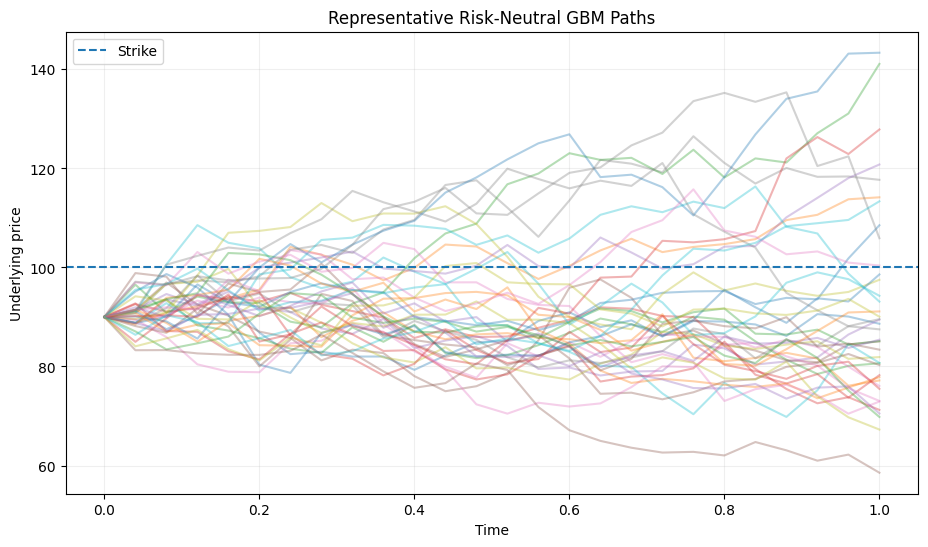

In [4]:
plt.figure(figsize=(11, 6))
time_grid = np.linspace(
    0.0,
    representative_contract.time_to_maturity,
    profile["exercise_steps"] + 1,
)
for path in representative_paths[:40]:
    plt.plot(time_grid, path, alpha=0.35)
plt.axhline(representative_contract.strike, linestyle="--", label="Strike")
plt.xlabel("Time")
plt.ylabel("Underlying price")
plt.title("Representative Risk-Neutral GBM Paths")
plt.legend()
plt.grid(alpha=0.20)
plt.show()

The path chart is illustrative only. The numerical validation comes from the terminal moments: the simulated mean differs from theory by 0.01%, while the variance differs by 0.54%.

These deviations are small enough for the later pricing experiment. Any material difference between classical and neural LSM is therefore unlikely to come from an obvious failure of the GBM simulator.


## 5. Classical Longstaff–Schwartz benchmark

Classical LSM requires a choice of regression basis. Three predefined specifications are compared across the complete validation-contract set:

- polynomial degree 2;
- polynomial degree 3;
- Laguerre degree 3.

Every candidate uses the same policy and valuation paths for each contract. Selection is based on aggregate validation MAE against the CRR benchmark and is completed before the test-contract results are inspected.


In [5]:
in_domain_ranges = {
    key: tuple(value)
    for key, value in experiment_design["in_domain_ranges"].items()
}

basis_validation_contracts = sample_contracts_latin_hypercube(
    n_contracts=profile["validation_contracts"],
    parameter_ranges=in_domain_ranges,
    seed=SEED + 450,
    prefix="basis_validation",
)

basis_validation_rows = []

for contract_index, contract in tqdm(
    enumerate(basis_validation_contracts),
    total=len(basis_validation_contracts),
    desc="Classical basis validation",
    unit="contract",
):
    policy_paths = simulate_contract_paths(
        contract,
        n_paths=profile["policy_training_paths_per_contract"],
        n_steps=profile["exercise_steps"],
        seed=SEED + 10_000 + contract_index,
    )
    valuation_paths = simulate_contract_paths(
        contract,
        n_paths=profile["valuation_paths_per_contract"],
        n_steps=profile["exercise_steps"],
        seed=SEED + 20_000 + contract_index,
    )
    crr_price = crr_option_price(
        spot=contract.spot,
        strike=contract.strike,
        time_to_maturity=contract.time_to_maturity,
        risk_free_rate=contract.risk_free_rate,
        dividend_yield=contract.dividend_yield,
        volatility=contract.volatility,
        steps=experiment_design["crr_benchmark_steps"],
        option_type="put",
        exercise_style="american",
    )

    for candidate in experiment_design["classical_basis_candidates"]:
        started = time.perf_counter()
        result = longstaff_schwartz_put_price(
            policy_paths,
            valuation_paths,
            strike=contract.strike,
            time_to_maturity=contract.time_to_maturity,
            risk_free_rate=contract.risk_free_rate,
            basis=candidate["basis"],
            degree=candidate["degree"],
        )
        runtime = time.perf_counter() - started
        pair_summary = antithetic_pair_summary(
            result.valuation.discounted_payoffs
        )
        specification = (
            f"{candidate['basis']}_degree_{candidate['degree']}"
        )

        basis_validation_rows.append(
            {
                "contract_id": contract.contract_id,
                "specification": specification,
                "basis": candidate["basis"],
                "degree": int(candidate["degree"]),
                "crr_price": crr_price,
                "lsm_price": pair_summary["price"],
                "standard_error": pair_summary["standard_error"],
                "ci_low": pair_summary["confidence_interval_low"],
                "ci_high": pair_summary["confidence_interval_high"],
                "absolute_error_vs_crr": abs(
                    pair_summary["price"] - crr_price
                ),
                "runtime_seconds": runtime,
            }
        )

basis_validation_contract_results = pd.DataFrame(
    basis_validation_rows
)

basis_summary_rows = []
for specification, subset in basis_validation_contract_results.groupby(
    "specification",
    observed=True,
):
    metrics = pricing_error_metrics(
        subset["crr_price"],
        subset["lsm_price"],
    )
    basis_summary_rows.append(
        {
            "specification": specification,
            "basis": subset["basis"].iloc[0],
            "degree": int(subset["degree"].iloc[0]),
            "contracts": int(len(subset)),
            **metrics,
            "mean_runtime_seconds": float(
                subset["runtime_seconds"].mean()
            ),
            "ci_coverage": confidence_interval_coverage(
                subset["crr_price"],
                subset["ci_low"],
                subset["ci_high"],
            ),
        }
    )

basis_results = (
    pd.DataFrame(basis_summary_rows)
    .sort_values(["mae", "rmse"])
    .reset_index(drop=True)
)
basis_results

Classical basis validation: 100%|██████████| 50/50 [01:12<00:00,  1.45s/contract]


,specification,basis,degree,contracts,mae,rmse,median_absolute_error,maximum_absolute_error,mean_bias,normalized_mae,mean_runtime_seconds,ci_coverage
0,polynomial_degree_3,polynomial,3,50,0.036525,0.056699,0.020537,0.182010,-0.027266,0.002328,0.224949,0.72
1,laguerre_degree_3,laguerre,3,50,0.038438,0.059678,0.027852,0.185134,-0.030420,0.002476,0.307382,0.70
2,polynomial_degree_2,polynomial,2,50,0.051965,0.080331,0.027018,0.269343,-0.044513,0.003351,0.212756,0.58


In [6]:
selected_classical_row = basis_results.iloc[0]

BEST_CLASSICAL_SPECIFICATION = str(
    selected_classical_row["specification"]
)
BEST_CLASSICAL_BASIS = str(
    selected_classical_row["basis"]
)
BEST_CLASSICAL_DEGREE = int(
    selected_classical_row["degree"]
)

crr_representative = crr_option_price(
    spot=representative_contract.spot,
    strike=representative_contract.strike,
    time_to_maturity=representative_contract.time_to_maturity,
    risk_free_rate=representative_contract.risk_free_rate,
    dividend_yield=representative_contract.dividend_yield,
    volatility=representative_contract.volatility,
    steps=experiment_design["crr_benchmark_steps"],
    option_type="put",
    exercise_style="american",
)

print(f"Representative CRR benchmark: {crr_representative:.6f}")
print(
    "Selected classical specification: "
    f"{BEST_CLASSICAL_SPECIFICATION}"
)

Representative CRR benchmark: 11.762210
Selected classical specification: polynomial_degree_3


### Classical basis selection

Polynomial degree 3 is selected with validation MAE of 0.0365. Laguerre degree 3 is close at 0.0384, while polynomial degree 2 is weaker at 0.0520.

The difference between the two leading specifications is small, so this should not be read as a universal ranking of basis functions. It is a validation-based choice for the contract domain and simulation budget used in this project.


## 6. Path-count convergence

Monte Carlo pricing should be considered together with sampling uncertainty. The next experiment increases both the policy-fitting and valuation path counts while keeping the two samples independent.

Each path budget is evaluated over three seeds, so the comparison reflects repeated simulation rather than one favourable random draw.


In [7]:
path_counts = [2_000, 5_000, 10_000]
if PROFILE != "smoke":
    path_counts.extend([25_000, 50_000])

path_convergence_rows = []
maximum_policy_paths = max(path_counts)
maximum_valuation_paths = 2 * maximum_policy_paths

for seed in experiment_design["seeds"]:
    full_training_paths = simulate_contract_paths(
        representative_contract,
        n_paths=maximum_policy_paths,
        n_steps=profile["exercise_steps"],
        seed=int(seed) + 100,
    )
    full_valuation_paths = simulate_contract_paths(
        representative_contract,
        n_paths=maximum_valuation_paths,
        n_steps=profile["exercise_steps"],
        seed=int(seed) + 200,
    )

    for count in path_counts:
        train_sample = nested_antithetic_subset(
            full_training_paths,
            count,
        )
        valuation_sample = nested_antithetic_subset(
            full_valuation_paths,
            2 * count,
        )

        started = time.perf_counter()
        experiment = longstaff_schwartz_put_price(
            train_sample,
            valuation_sample,
            strike=representative_contract.strike,
            time_to_maturity=representative_contract.time_to_maturity,
            risk_free_rate=representative_contract.risk_free_rate,
            basis=BEST_CLASSICAL_BASIS,
            degree=BEST_CLASSICAL_DEGREE,
        )
        runtime = time.perf_counter() - started
        pair_summary = antithetic_pair_summary(
            experiment.valuation.discounted_payoffs
        )

        path_convergence_rows.append(
            {
                "seed": int(seed),
                "policy_paths": count,
                "valuation_paths": 2 * count,
                "price": pair_summary["price"],
                "standard_error": pair_summary["standard_error"],
                "ci_low": pair_summary["confidence_interval_low"],
                "ci_high": pair_summary["confidence_interval_high"],
                "absolute_error_vs_crr": abs(
                    pair_summary["price"] - crr_representative
                ),
                "crr_covered": (
                    pair_summary["confidence_interval_low"]
                    <= crr_representative
                    <= pair_summary["confidence_interval_high"]
                ),
                "runtime_seconds": runtime,
            }
        )

path_convergence_seed_results = pd.DataFrame(
    path_convergence_rows
)

path_convergence = (
    path_convergence_seed_results
    .groupby(
        ["policy_paths", "valuation_paths"],
        as_index=False,
    )
    .agg(
        seeds=("seed", "count"),
        mean_price=("price", "mean"),
        price_std=("price", "std"),
        mean_standard_error=("standard_error", "mean"),
        mean_absolute_error_vs_crr=(
            "absolute_error_vs_crr",
            "mean",
        ),
        absolute_error_std=("absolute_error_vs_crr", "std"),
        ci_coverage=("crr_covered", "mean"),
        mean_runtime_seconds=("runtime_seconds", "mean"),
    )
)

path_convergence

,policy_paths,valuation_paths,seeds,mean_price,price_std,mean_standard_error,mean_absolute_error_vs_crr,absolute_error_std,ci_coverage,mean_runtime_seconds
0,2000,4000,3,11.764427,0.071888,0.074684,0.054137,0.027911,1.000000,0.031847
1,5000,10000,3,11.695159,0.018149,0.047637,0.067051,0.018149,1.000000,0.058176
2,10000,20000,3,11.726205,0.024739,0.033695,0.036005,0.024739,1.000000,0.096678
3,25000,50000,3,11.737018,0.008546,0.021360,0.025193,0.008546,1.000000,0.223236
4,50000,100000,3,11.732702,0.012504,0.015209,0.029508,0.012504,0.666667,0.554108


### Path-count result

Sampling uncertainty declines as the path budget increases, as expected. Absolute error is not perfectly monotonic because each estimate remains subject to Monte Carlo variation.

The final choice of 25,000 policy paths and 50,000 valuation paths gives the best mean absolute error in this study, 0.0252 price units, at a manageable runtime. Doubling the budget to 50,000 and 100,000 paths more than doubles runtime without improving the mean error.


## 7. Exercise-date convergence

The American put may be exercised continuously, while LSM evaluates only a finite set of dates. More exercise dates reduce this discretization gap but increase:

- the number of classical regressions;
- the number of neural continuation networks;
- training time;
- policy-evaluation time.

The experiment compares 10, 25, and 50 exercise dates over three seeds.


In [8]:
exercise_step_grid = [10, 25, 50]
if PROFILE == "smoke":
    exercise_step_grid = [5, 10, 20]

exercise_date_rows = []

for seed in experiment_design["seeds"]:
    for n_steps in exercise_step_grid:
        train_sample = simulate_contract_paths(
            representative_contract,
            n_paths=profile["policy_training_paths_per_contract"],
            n_steps=n_steps,
            seed=int(seed) + 300,
        )
        valuation_sample = simulate_contract_paths(
            representative_contract,
            n_paths=profile["valuation_paths_per_contract"],
            n_steps=n_steps,
            seed=int(seed) + 400,
        )

        started = time.perf_counter()
        experiment = longstaff_schwartz_put_price(
            train_sample,
            valuation_sample,
            strike=representative_contract.strike,
            time_to_maturity=representative_contract.time_to_maturity,
            risk_free_rate=representative_contract.risk_free_rate,
            basis=BEST_CLASSICAL_BASIS,
            degree=BEST_CLASSICAL_DEGREE,
        )
        runtime = time.perf_counter() - started
        pair_summary = antithetic_pair_summary(
            experiment.valuation.discounted_payoffs
        )

        exercise_date_rows.append(
            {
                "seed": int(seed),
                "exercise_steps": n_steps,
                "price": pair_summary["price"],
                "standard_error": pair_summary["standard_error"],
                "absolute_error_vs_crr": abs(
                    pair_summary["price"] - crr_representative
                ),
                "runtime_seconds": runtime,
            }
        )

exercise_date_seed_results = pd.DataFrame(
    exercise_date_rows
)

exercise_date_convergence = (
    exercise_date_seed_results
    .groupby("exercise_steps", as_index=False)
    .agg(
        seeds=("seed", "count"),
        mean_price=("price", "mean"),
        price_std=("price", "std"),
        mean_standard_error=("standard_error", "mean"),
        mean_absolute_error_vs_crr=(
            "absolute_error_vs_crr",
            "mean",
        ),
        absolute_error_std=("absolute_error_vs_crr", "std"),
        mean_runtime_seconds=("runtime_seconds", "mean"),
    )
)

exercise_date_convergence

,exercise_steps,seeds,mean_price,price_std,mean_standard_error,mean_absolute_error_vs_crr,absolute_error_std,mean_runtime_seconds
0,10,3,11.697369,0.020110,0.021538,0.064842,0.020110,0.064867
1,25,3,11.710719,0.023712,0.021222,0.051492,0.023712,0.221322
2,50,3,11.730140,0.031720,0.021530,0.032076,0.031711,0.404143


### Exercise-date result

Fifty exercise dates give the lowest representative error, approximately 0.0321 price units. The final experiment retains 25 dates as a computational compromise.

This is not a claim that 25 dates are numerically optimal. It limits the number of classical regressions and neural networks while keeping representative error materially below the 10-date result.


## 8. Contract-level research design

The neural policy is trained across a domain rather than fitted separately for each new contract.

The final experiment uses:

- 200 training contracts;
- 50 validation contracts;
- 100 held-out test contracts;
- 25 exercise dates.

Training, validation, and test contract identifiers are disjoint.

One continuation network is trained for every non-terminal exercise date, giving 24 time-indexed networks in total. Each network receives:

$$
x_t
=
\left[
\log(S_t/K),\;
T-t,\;
r,\;
q,\;
\sigma
\right].
$$

Where:

- $\log(S_t/K)$ is current log-moneyness;
- $T-t$ is remaining time to maturity;
- $r$ is the risk-free rate;
- $q$ is the dividend yield;
- $\sigma$ is volatility.

The target is the discounted future cash flow under the current backward-induction policy, normalized by strike.


In [9]:
training_contracts = sample_contracts_latin_hypercube(
    n_contracts=profile["training_contracts"],
    parameter_ranges=in_domain_ranges,
    seed=SEED + 500,
    prefix="train",
)
validation_contracts = sample_contracts_latin_hypercube(
    n_contracts=profile["validation_contracts"],
    parameter_ranges=in_domain_ranges,
    seed=SEED + 600,
    prefix="validation",
)
test_contracts = sample_contracts_latin_hypercube(
    n_contracts=profile["test_contracts"],
    parameter_ranges=in_domain_ranges,
    seed=SEED + 700,
    prefix="test",
)

contract_sets = {
    "basis_validation": basis_validation_contracts,
    "training": training_contracts,
    "validation": validation_contracts,
    "test": test_contracts,
}
contract_id_sets = {
    name: {contract.contract_id for contract in contracts}
    for name, contracts in contract_sets.items()
}

for left_name, left_ids in contract_id_sets.items():
    for right_name, right_ids in contract_id_sets.items():
        if left_name >= right_name:
            continue
        overlap = left_ids & right_ids
        if overlap:
            raise ValueError(
                f"Contract leakage between {left_name} and "
                f"{right_name}: {sorted(overlap)}"
            )

contract_grid = pd.DataFrame(
    [
        {**contract.to_dict(), "sample": sample}
        for sample, contracts in [
            ("training", training_contracts),
            ("validation", validation_contracts),
            ("test", test_contracts),
        ]
        for contract in contracts
    ]
)

print("All contract ID sets are disjoint.")
contract_grid.groupby("sample").size().to_frame("contracts")

All contract ID sets are disjoint.


,contracts
sample,
test,100
training,200
validation,50


In [10]:
network_config = ContinuationNetworkConfig(
    input_dim=5,
    hidden_dims=(64, 64, 32),
    dropout=0.0,
)

training_config = NeuralLSMTrainingConfig(
    network=network_config,
    epochs=profile["neural_epochs_per_step"],
    batch_size=1024,
    learning_rate=1e-3,
    weight_decay=1e-5,
    patience=max(
        3,
        min(
            8,
            profile["neural_epochs_per_step"] // 3,
        ),
    ),
    minimum_samples_per_step=64,
    maximum_samples_per_step=profile[
        "max_training_samples_per_step"
    ],
    warm_start_from_later_step=True,
    seed=SEED,
    device=DEVICE,
)

training_dependency_config = asdict(training_config)
training_dependency_config.pop("device", None)
training_dependency_config.pop("verbose", None)
training_dependency_config.pop("epoch_report_interval", None)

current_training_dependencies = json.loads(
    json.dumps(
        {
            "experiment_config": {
                "path": str(CONFIG_PATH.relative_to(PROJECT_ROOT)),
                "sha256": calculate_file_sha256(CONFIG_PATH),
            },
            "profile": PROFILE,
            "profile_settings": dict(profile),
            "network_config": asdict(network_config),
            "training_config": training_dependency_config,
            "seed": SEED,
        },
        sort_keys=True,
    )
)

representative_continuation_network = ContinuationValueNetwork(
    network_config
).to(DEVICE)

summary(
    representative_continuation_network,
    input_size=(1, network_config.input_dim),
    device=DEVICE,
    col_names=("input_size", "output_size", "num_params", "trainable"),
)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
ContinuationValueNetwork                 [1, 5]                    [1]                       --                        True
├─Sequential: 1-1                        [1, 5]                    [1, 1]                    --                        True
│    └─Linear: 2-1                       [1, 5]                    [1, 64]                   384                       True
│    └─SiLU: 2-2                         [1, 64]                   [1, 64]                   --                        --
│    └─Linear: 2-3                       [1, 64]                   [1, 64]                   4,160                     True
│    └─SiLU: 2-4                         [1, 64]                   [1, 64]                   --                        --
│    └─Linear: 2-5                       [1, 64]                   [1, 32]                   2,080                     True
│    └─

### Neural architecture

Each continuation network has 6,657 parameters. With 24 exercise-time networks, the policy contains approximately 160,000 trainable parameters in total, together with a separate feature standardizer for each date.

The model is compact at each step, but the full policy is substantially more complex than the small contract-specific regressions used by classical LSM.


In [11]:
existing_history_path = (
    HISTORY_PARQUET_PATH
    if HISTORY_PARQUET_PATH.is_file()
    else HISTORY_CSV_PATH
)

if (
    BACKFILL_LEGACY_DEPENDENCIES
    and not FORCE_TRAIN
    and TRAINING_MANIFEST_PATH.is_file()
):
    try:
        existing_manifest = json.loads(
            TRAINING_MANIFEST_PATH.read_text(
                encoding="utf-8"
            )
        )
    except (OSError, json.JSONDecodeError):
        existing_manifest = {}

    if (
        existing_manifest.get("status") == "complete"
        and "dependencies" not in existing_manifest
    ):
        existing_manifest["dependencies"] = (
            current_training_dependencies
        )
        existing_manifest[
            "dependency_metadata_backfilled"
        ] = True
        write_training_manifest(
            TRAINING_MANIFEST_PATH,
            existing_manifest,
        )
        print(
            "Added dependency fingerprints to the existing "
            "neural LSM training manifest."
        )

training_outputs_available, availability_reason = inspect_training_artifacts(
    TRAINING_MANIFEST_PATH,
    [
        POLICY_PATH,
        existing_history_path,
        TRAINING_CONFIG_PATH,
    ],
    expected_notebook="07_neural_longstaff_schwartz",
    expected_profile=TRAINING_PROFILE,
    expected_dependencies=current_training_dependencies,
)

RUN_NEURAL_TRAINING = (
    FORCE_TRAIN or not training_outputs_available
)

print(f"Force training:             {FORCE_TRAIN}")
print(f"Training outputs available: {training_outputs_available}")
print(
    "Decision:                   "
    f"{'train' if RUN_NEURAL_TRAINING else 'load'}"
)
print(f"Artifact check:             {availability_reason}")

if RUN_NEURAL_TRAINING:
    TRAINING_MANIFEST_PATH.unlink(missing_ok=True)
    training_batches = build_contract_path_batches(
        training_contracts,
        n_paths=profile[
            "policy_training_paths_per_contract"
        ],
        n_steps=profile["exercise_steps"],
        base_seed=SEED,
        seed_offset=1_000,
        description="Training path generation",
    )

    validation_batches = build_contract_path_batches(
        validation_contracts,
        n_paths=profile[
            "policy_training_paths_per_contract"
        ],
        n_steps=profile["exercise_steps"],
        base_seed=SEED,
        seed_offset=2_000,
        description="Validation path generation",
    )
else:
    training_batches = []
    validation_batches = []
    print(
        "Saved neural LSM policy found. "
        "Training and validation path generation skipped."
    )


Force training:             False
Training outputs available: True
Decision:                   load
Artifact check:             complete compatible package found
Saved neural LSM policy found. Training and validation path generation skipped.


## 9. Neural continuation-policy training

Each continuation network uses the same compact architecture:

```text
Input(5)
→ Linear(64)
→ SiLU
→ Linear(64)
→ SiLU
→ Linear(32)
→ SiLU
→ Linear(1)
→ Softplus
```

Each network has 6,657 trainable parameters. The `Softplus` output keeps the estimated continuation value non-negative.

Training proceeds backward through time. The network for a later exercise date is trained first, and its weights may initialize the preceding network. Earlier continuation values are harder because they depend on a longer sequence of future stopping decisions.

`FORCE_TRAIN = False` loads the completed policy and training history when compatible artifacts are available. The held-out contracts and their valuation paths remain outside policy training.


In [12]:
if RUN_NEURAL_TRAINING:
    neural_training_started = time.perf_counter()
    neural_policy, neural_training_history = (
        fit_neural_lsm_policy(
            training_batches,
            validation_batches,
            config=training_config,
        )
    )
    neural_training_runtime = (
        time.perf_counter() - neural_training_started
    )

    neural_policy.save(POLICY_PATH)
    try:
        neural_training_history.to_parquet(
            HISTORY_PARQUET_PATH,
            index=False,
        )
        saved_history_path = HISTORY_PARQUET_PATH
        if HISTORY_CSV_PATH.exists():
            HISTORY_CSV_PATH.unlink()
    except ImportError:
        neural_training_history.to_csv(
            HISTORY_CSV_PATH,
            index=False,
        )
        saved_history_path = HISTORY_CSV_PATH

    TRAINING_CONFIG_PATH.write_text(
        json.dumps(asdict(training_config), indent=2),
        encoding="utf-8",
    )

    maximum_epoch = (
        int(neural_training_history["epoch"].max())
        if not neural_training_history.empty
        else 0
    )
    write_training_manifest(
        TRAINING_MANIFEST_PATH,
        {
            "status": "complete",
            "notebook": "07_neural_longstaff_schwartz",
            "training_profile": TRAINING_PROFILE,
            "dependencies": current_training_dependencies,
            "requested_epochs_per_step": int(
                training_config.epochs
            ),
            "maximum_epochs_completed_per_step": (
                maximum_epoch
            ),
            "trained_continuation_steps": len(
                neural_policy.steps
            ),
            "training_runtime_seconds": float(
                neural_training_runtime
            ),
            "checkpoint": POLICY_PATH.name,
            "history": saved_history_path.name,
        },
    )
else:
    neural_policy = NeuralLSMPolicy.load(
        POLICY_PATH,
        map_location=DEVICE,
    )
    if HISTORY_PARQUET_PATH.is_file():
        neural_training_history = pd.read_parquet(
            HISTORY_PARQUET_PATH
        )
    else:
        neural_training_history = pd.read_csv(
            HISTORY_CSV_PATH
        )

    training_manifest = json.loads(
        TRAINING_MANIFEST_PATH.read_text(
            encoding="utf-8"
        )
    )
    neural_training_runtime = float(
        training_manifest.get(
            "training_runtime_seconds",
            float("nan"),
        )
    )

if neural_policy.n_steps != int(profile["exercise_steps"]):
    raise ValueError(
        "Loaded neural policy uses a different exercise-step count."
    )

expected_feature_names = (
    "log_moneyness",
    "time_remaining",
    "risk_free_rate",
    "dividend_yield",
    "volatility",
)
if tuple(neural_policy.feature_names) != expected_feature_names:
    raise ValueError(
        "Loaded neural policy feature order does not match the notebook."
    )

print(
    f"Continuation networks available: "
    f"{len(neural_policy.steps)}"
)
print(
    f"Recorded training runtime: "
    f"{neural_training_runtime:.2f} seconds"
)
neural_training_history.tail()

Continuation networks available: 24
Recorded training runtime: 628.05 seconds


,step_index,epoch,train_loss,validation_loss,learning_rate
350,1,6,0.009961,0.009321,0.001
351,1,7,0.009960,0.009326,0.001
352,1,8,0.009959,0.009321,0.001
353,1,9,0.009961,0.009323,0.001
354,1,10,0.009958,0.009328,0.001


### Training result

All 24 continuation networks are available and the saved policy loads successfully with `FORCE_TRAIN = False`. The recorded network-training time is 628 seconds.

Validation loss is lowest near maturity and rises toward the start of the option life. This is intuitive: earlier continuation values depend on more future stopping decisions and accumulate more policy uncertainty.


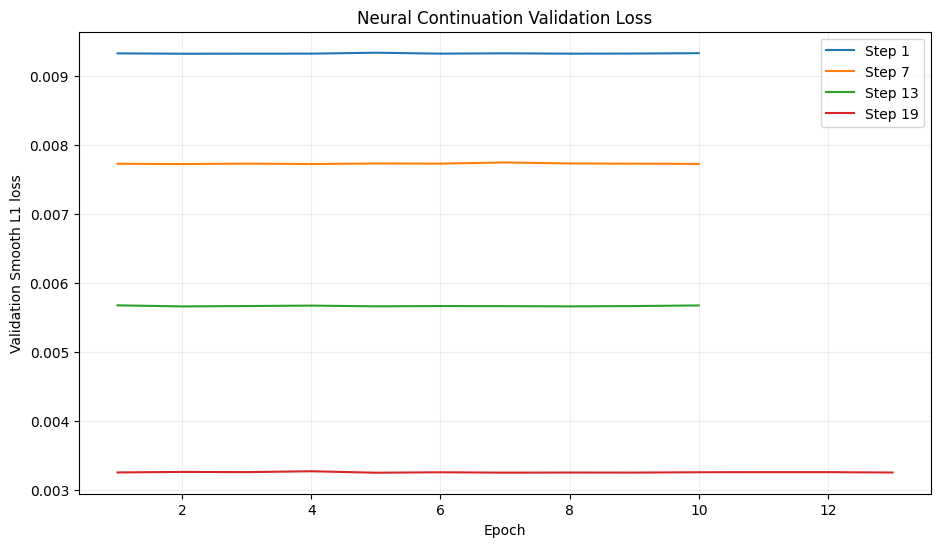

In [13]:
if not neural_training_history.empty:
    selected_steps = sorted(neural_training_history["step_index"].unique())
    selected_steps = selected_steps[:: max(len(selected_steps) // 4, 1)]
    plt.figure(figsize=(11, 6))
    for step_index in selected_steps:
        subset = neural_training_history[
            neural_training_history["step_index"] == step_index
        ]
        plt.plot(
            subset["epoch"],
            subset["validation_loss"],
            label=f"Step {step_index}",
        )
    plt.xlabel("Epoch")
    plt.ylabel("Validation Smooth L1 loss")
    plt.title("Neural Continuation Validation Loss")
    plt.legend()
    plt.grid(alpha=0.20)
    plt.show()

## 10. Held-out contract evaluation

For every held-out contract:

1. a 2,000-step CRR benchmark is calculated;
2. a classical policy is fitted on contract-specific policy paths;
3. the classical and neural policies are evaluated on the same independent valuation paths.

Using common valuation paths reduces comparison noise. Classical LSM is the contract-specific benchmark policy, while neural LSM is the amortized policy being tested.


In [14]:
heldout_rows = []
heldout_policy_rows = []
runtime_rows = []
contract_valuation_cache = {}

for index, contract in enumerate(
    tqdm(
        test_contracts,
        desc="Held-out contract evaluation",
        unit="contract",
    )
):
    started = time.perf_counter()
    policy_paths = simulate_contract_paths(
        contract,
        n_paths=profile["policy_training_paths_per_contract"],
        n_steps=profile["exercise_steps"],
        seed=SEED + 3_000 + index,
    )
    policy_simulation_runtime = time.perf_counter() - started

    started = time.perf_counter()
    valuation_paths = simulate_contract_paths(
        contract,
        n_paths=profile["valuation_paths_per_contract"],
        n_steps=profile["exercise_steps"],
        seed=SEED + 4_000 + index,
    )
    valuation_simulation_runtime = time.perf_counter() - started

    valuation_batch = ContractPathBatch(
        contract=contract,
        paths=valuation_paths,
    )

    started = time.perf_counter()
    classical = longstaff_schwartz_put_price(
        policy_paths,
        valuation_paths,
        strike=contract.strike,
        time_to_maturity=contract.time_to_maturity,
        risk_free_rate=contract.risk_free_rate,
        basis=BEST_CLASSICAL_BASIS,
        degree=BEST_CLASSICAL_DEGREE,
    )
    classical_runtime = time.perf_counter() - started

    started = time.perf_counter()
    neural = evaluate_neural_lsm_policy(
        neural_policy,
        valuation_batch,
        device=DEVICE,
    )
    neural_runtime = time.perf_counter() - started

    started = time.perf_counter()
    crr_price = crr_option_price(
        spot=contract.spot,
        strike=contract.strike,
        time_to_maturity=contract.time_to_maturity,
        risk_free_rate=contract.risk_free_rate,
        dividend_yield=contract.dividend_yield,
        volatility=contract.volatility,
        steps=experiment_design["crr_benchmark_steps"],
        option_type="put",
        exercise_style="american",
    )
    crr_runtime = time.perf_counter() - started

    classical_pair = antithetic_pair_summary(
        classical.valuation.discounted_payoffs
    )
    neural_pair = antithetic_pair_summary(
        neural.discounted_payoffs
    )

    intrinsic_value = max(
        contract.strike - contract.spot,
        0.0,
    )
    european_price = black_scholes_put_price(
        spot=contract.spot,
        strike=contract.strike,
        time_to_maturity=(
            contract.time_to_maturity
        ),
        risk_free_rate=(
            contract.risk_free_rate
        ),
        dividend_yield=(
            contract.dividend_yield
        ),
        volatility=contract.volatility,
    )

    heldout_rows.append(
        {
            "contract_id": contract.contract_id,
            "spot": contract.spot,
            "strike": contract.strike,
            "moneyness": contract.spot / contract.strike,
            "time_to_maturity": contract.time_to_maturity,
            "risk_free_rate": contract.risk_free_rate,
            "dividend_yield": contract.dividend_yield,
            "volatility": contract.volatility,
            "intrinsic_value": intrinsic_value,
            "european_price": european_price,
            "crr_price": crr_price,
            "classical_lsm_price": classical_pair["price"],
            "classical_lsm_standard_error": (
                classical_pair["standard_error"]
            ),
            "classical_lsm_ci_low": (
                classical_pair["confidence_interval_low"]
            ),
            "classical_lsm_ci_high": (
                classical_pair["confidence_interval_high"]
            ),
            "classical_early_exercise_rate": (
                classical.valuation.exercised_early_rate
            ),
            "neural_lsm_price": neural_pair["price"],
            "neural_lsm_standard_error": neural_pair["standard_error"],
            "neural_lsm_ci_low": (
                neural_pair["confidence_interval_low"]
            ),
            "neural_lsm_ci_high": (
                neural_pair["confidence_interval_high"]
            ),
            "neural_early_exercise_rate": neural.exercised_early_rate,
        }
    )

    policy_metrics = conditional_exercise_policy_metrics(
        classical.valuation.exercise_indices,
        neural.exercise_indices,
        maturity_index=profile["exercise_steps"],
    )
    policy_metrics["stopping_distribution_tv"] = (
        stopping_time_total_variation(
            classical.valuation.exercise_indices,
            neural.exercise_indices,
            n_steps=profile["exercise_steps"],
        )
    )
    payoff_difference = (
        classical.valuation.discounted_payoffs
        - neural.discounted_payoffs
    )
    policy_metrics[
        "mean_discounted_payoff_difference"
    ] = float(payoff_difference.mean())
    policy_metrics[
        "mean_neural_shortfall_vs_classical"
    ] = float(np.maximum(payoff_difference, 0.0).mean())

    heldout_policy_rows.append(
        {"contract_id": contract.contract_id, **policy_metrics}
    )

    classical_end_to_end = (
        policy_simulation_runtime
        + valuation_simulation_runtime
        + classical_runtime
    )
    neural_end_to_end = (
        valuation_simulation_runtime
        + neural_runtime
    )

    runtime_rows.extend(
        [
            {
                "contract_id": contract.contract_id,
                "method": "Policy path simulation",
                "runtime_seconds": policy_simulation_runtime,
            },
            {
                "contract_id": contract.contract_id,
                "method": "Valuation path simulation",
                "runtime_seconds": valuation_simulation_runtime,
            },
            {
                "contract_id": contract.contract_id,
                "method": "Classical LSM fit and valuation",
                "runtime_seconds": classical_runtime,
            },
            {
                "contract_id": contract.contract_id,
                "method": "Neural LSM evaluation",
                "runtime_seconds": neural_runtime,
            },
            {
                "contract_id": contract.contract_id,
                "method": "CRR",
                "runtime_seconds": crr_runtime,
            },
            {
                "contract_id": contract.contract_id,
                "method": "Classical LSM end-to-end",
                "runtime_seconds": classical_end_to_end,
            },
            {
                "contract_id": contract.contract_id,
                "method": "Neural LSM end-to-end",
                "runtime_seconds": neural_end_to_end,
            },
        ]
    )

    contract_valuation_cache[contract.contract_id] = {
        "classical": classical.valuation,
        "neural": neural,
    }

heldout_results = pd.DataFrame(heldout_rows)
heldout_policy_metrics = pd.DataFrame(heldout_policy_rows)
runtime_records = pd.DataFrame(runtime_rows)

print(heldout_results.head())
print("Held-out pricing rows:", len(heldout_results))
print("Policy metric rows:", len(heldout_policy_metrics))
print("Runtime rows:", len(runtime_records))

Held-out contract evaluation: 100%|██████████| 100/100 [02:28<00:00,  1.49s/contract]

  contract_id        spot  strike  moneyness  time_to_maturity  \
0   test_0000  107.162311   100.0   1.071623          1.698379   
1   test_0001  109.218832   100.0   1.092188          1.173842   
2   test_0002   84.294595   100.0   0.842946          0.193547   
3   test_0003   85.015282   100.0   0.850153          0.545640   
4   test_0004   95.420033   100.0   0.954200          1.958273   

   risk_free_rate  dividend_yield  volatility  intrinsic_value  \
0        0.077371        0.021302    0.600715         0.000000   
1        0.090714        0.069425    0.485915         0.000000   
2        0.093971        0.068042    0.325971        15.705405   
3        0.097865        0.025849    0.212949        14.984718   
4        0.068491        0.024782    0.241919         4.579967   

   european_price  ...  classical_lsm_price  classical_lsm_standard_error  \
0       21.859250  ...            23.125135                  4.000835e-02   
1       14.841982  ...            15.325871         

In [15]:
heldout_comparison = compare_lsm_methods(
    heldout_results,
    benchmark_column="crr_price",
    method_columns=[
        "classical_lsm_price",
        "neural_lsm_price",
    ],
)

heldout_mae_bootstrap = pd.DataFrame(
    [
        paired_mae_bootstrap(
            heldout_results["crr_price"],
            heldout_results["classical_lsm_price"],
            heldout_results["neural_lsm_price"],
            seed=SEED,
        )
    ]
)

heldout_error_distribution = error_distribution_table(
    heldout_results,
    benchmark_column="crr_price",
    method_columns=[
        "classical_lsm_price",
        "neural_lsm_price",
    ],
)

heldout_segment_frame = heldout_results.copy()
heldout_segment_frame["moneyness_segment"] = pd.cut(
    heldout_segment_frame["moneyness"],
    bins=[0.0, 0.80, 0.95, 1.05, 1.20, np.inf],
    labels=[
        "deep ITM",
        "ITM",
        "near ATM",
        "OTM",
        "deep OTM",
    ],
)
heldout_segment_frame["maturity_segment"] = pd.cut(
    heldout_segment_frame["time_to_maturity"],
    bins=[0.0, 0.50, 1.00, 1.50, np.inf],
    labels=["short", "medium", "long", "very long"],
)
heldout_segment_frame["volatility_segment"] = pd.cut(
    heldout_segment_frame["volatility"],
    bins=[0.0, 0.20, 0.35, 0.50, np.inf],
    labels=["low", "medium", "high", "very high"],
)
heldout_segment_frame["exercise_rate_segment"] = pd.cut(
    heldout_segment_frame["classical_early_exercise_rate"],
    bins=[-1e-12, 0.25, 0.50, 0.75, 1.0 + 1e-12],
    labels=[
        "mostly maturity",
        "mixed-low",
        "mixed-high",
        "mostly early",
    ],
)

heldout_segmented_errors = segmented_pricing_errors(
    heldout_segment_frame,
    segment_columns=[
        "moneyness_segment",
        "maturity_segment",
        "volatility_segment",
        "exercise_rate_segment",
    ],
    benchmark_column="crr_price",
    method_columns=[
        "classical_lsm_price",
        "neural_lsm_price",
    ],
)

display(heldout_comparison)
display(heldout_mae_bootstrap)
display(heldout_error_distribution)
display(heldout_segmented_errors)

,method,mae,rmse,median_absolute_error,maximum_absolute_error,mean_bias,normalized_mae
0,classical_lsm_price,0.039594,0.052043,0.032319,0.127381,-0.033838,0.004014
1,neural_lsm_price,0.087197,0.121771,0.063737,0.400425,-0.084348,0.006911


,neural_minus_classical_mae,ci_low,ci_high,probability_neural_is_better,resamples
0,0.047603,0.032891,0.063968,0.0,10000


,group,method,observations,negative_error_rate,positive_error_rate,mean_error,q05_error,median_error,q95_error,mae,maximum_absolute_error
0,all,classical_lsm_price,100,0.87,0.13,-0.033838,-0.112169,-0.026566,0.024245,0.039594,0.127381
1,all,neural_lsm_price,100,0.91,0.09,-0.084348,-0.263456,-0.063737,0.007212,0.087197,0.400425


,segment_type,segment,method,observations,mae,rmse,median_absolute_error,maximum_absolute_error,mean_bias,normalized_mae
0,moneyness_segment,deep ITM,classical_lsm_price,25,0.046341,0.061860,0.046825,0.127381,-0.041919,0.001467
1,moneyness_segment,deep ITM,neural_lsm_price,25,0.135721,0.178549,0.119285,0.392335,-0.135650,0.004454
2,moneyness_segment,ITM,classical_lsm_price,25,0.047087,0.058592,0.044299,0.117548,-0.041331,0.002066
3,moneyness_segment,ITM,neural_lsm_price,25,0.110687,0.137016,0.089231,0.400425,-0.110687,0.005253
4,moneyness_segment,near ATM,classical_lsm_price,17,0.047791,0.057384,0.042207,0.123261,-0.047185,0.005272
5,moneyness_segment,near ATM,neural_lsm_price,17,0.082077,0.092166,0.066530,0.175900,-0.082077,0.010826
6,moneyness_segment,OTM,classical_lsm_price,24,0.024389,0.032409,0.020039,0.093299,-0.015486,0.005785
7,moneyness_segment,OTM,neural_lsm_price,24,0.038787,0.050299,0.039810,0.148254,-0.030352,0.007742
8,moneyness_segment,deep OTM,classical_lsm_price,9,0.025100,0.030130,0.021503,0.047693,-0.014301,0.009400
9,moneyness_segment,deep OTM,neural_lsm_price,9,0.025923,0.035551,0.010520,0.073415,-0.016958,0.008729


### Held-out pricing result

Classical LSM is materially stronger on the 100 held-out contracts. Its MAE is 0.0396 price units, compared with 0.0872 for neural LSM.

The neural-minus-classical MAE difference is 0.0476, with a 95% paired-bootstrap interval from 0.0329 to 0.0640. None of the 10,000 resamples favours the neural policy.

The segmented results tell the same story. Neural weakness is most visible for deep in-the-money, longer-maturity, and higher-volatility contracts. The methods are closest for deep out-of-the-money puts, where option values and early-exercise effects are small.


In [16]:
coverage_summary = pd.Series(
    {
        "Classical LSM 95% CI coverage": confidence_interval_coverage(
            heldout_results["crr_price"],
            heldout_results["classical_lsm_ci_low"],
            heldout_results["classical_lsm_ci_high"],
        ),
        "Neural LSM 95% CI coverage": confidence_interval_coverage(
            heldout_results["crr_price"],
            heldout_results["neural_lsm_ci_low"],
            heldout_results["neural_lsm_ci_high"],
        ),
    }
)

heldout_financial_bounds = pricing_bound_report(
    heldout_results,
    method_columns=[
        "classical_lsm_price",
        "neural_lsm_price",
    ],
)

display(coverage_summary.to_frame("Coverage"))
display(heldout_financial_bounds)

,Coverage
Classical LSM 95% CI coverage,0.68
Neural LSM 95% CI coverage,0.42


,method,check,violations,violation_rate,maximum_violation,mean_positive_violation
0,classical_lsm_price,negative_price,0,0.00,0.000000e+00,0.000000e+00
1,classical_lsm_price,below_intrinsic,4,0.04,1.421085e-14,1.065814e-14
2,classical_lsm_price,below_european,23,0.23,7.367725e-02,2.309322e-02
3,neural_lsm_price,negative_price,0,0.00,0.000000e+00,0.000000e+00
4,neural_lsm_price,below_intrinsic,5,0.05,1.421085e-14,8.881784e-15
5,neural_lsm_price,below_european,31,0.31,3.999538e-01,1.147124e-01


### Confidence intervals and financial bounds

Classical 95% intervals cover the CRR benchmark for 68% of contracts; neural intervals cover it for 42%. Neither reaches nominal coverage because the intervals capture valuation-path noise but not the full uncertainty of the estimated stopping policy.

The few intrinsic-value violations are around $10^{-14}$ and are floating-point noise. The below-European violations are real: they affect 23% of classical prices and 31% of neural prices, with a much larger maximum neural shortfall.


In [17]:
heldout_policy_summary = (
    heldout_policy_metrics
    .describe()
    .T
)

heldout_policy_summary

,count,mean,std,min,25%,50%,75%,max
exact_step_agreement,100.0,0.658710,0.246566,0.000000,0.537000,0.688110,0.823110,1.000000
mean_absolute_step_error,100.0,1.414097,1.937613,0.000000,0.390540,0.863020,1.585565,12.303340
early_exercise_agreement,100.0,0.887792,0.172282,0.102480,0.891620,0.945200,0.969000,1.000000
false_early_exercise_count,100.0,5109.080000,8724.523158,0.000000,836.500000,2245.000000,5025.500000,44876.000000
false_early_exercise_rate,100.0,0.188116,0.235879,0.000000,0.030360,0.090860,0.271058,1.000000
missed_early_exercise_count,100.0,501.320000,1106.694321,0.000000,37.250000,208.500000,455.250000,9211.000000
missed_early_exercise_rate,100.0,0.049191,0.133510,0.000000,0.002762,0.011227,0.034936,0.942013
stopping_distribution_tv,100.0,0.267091,0.219760,0.000000,0.131780,0.224860,0.366055,1.000000
mean_discounted_payoff_difference,100.0,0.050510,0.080918,-0.028605,0.000383,0.024376,0.061940,0.390507
mean_neural_shortfall_vs_classical,100.0,0.932019,0.754459,0.000000,0.390400,0.800138,1.245133,3.897485


### Stopping-policy comparison

The policies agree on early exercise versus maturity for 88.8% of paths, but exact exercise-step agreement is only 65.9%. Their mean absolute difference is 1.41 exercise steps.

The neural policy also produces lower discounted payoffs on most contracts. This provides a direct stopping-policy explanation for its stronger underpricing.


Pricing agreement and stopping-policy agreement answer different questions. Two policies can produce similar average values while exercising different paths at different dates.

The stopping analysis therefore measures agreement with classical LSM. It does not treat the classical policy as the unknown true optimal pathwise policy.


## 11. Out-of-domain evaluation

Four OOD regimes isolate different forms of extrapolation:

- volatility above the training range;
- extreme in-the-money and out-of-the-money contracts;
- maturities beyond the training maximum;
- jointly elevated risk-free and dividend rates.

Within each contract, classical and neural LSM use the same valuation paths. This keeps the comparison focused on the stopping policies rather than different Monte Carlo draws.


In [18]:
ood_contract_sets = {}

high_volatility_ranges = dict(in_domain_ranges)
high_volatility_ranges["volatility"] = (0.80, 1.20)
ood_contract_sets["high_volatility"] = (
    sample_contracts_latin_hypercube(
        n_contracts=profile["ood_contracts"],
        parameter_ranges=high_volatility_ranges,
        seed=SEED + 5_000,
        prefix="ood_high_volatility",
    )
)

extreme_count = profile["ood_contracts"]
deep_itm_count = extreme_count // 2
deep_otm_count = extreme_count - deep_itm_count

deep_itm_ranges = dict(in_domain_ranges)
deep_itm_ranges["moneyness"] = (0.25, 0.50)
deep_otm_ranges = dict(in_domain_ranges)
deep_otm_ranges["moneyness"] = (1.50, 2.00)

ood_contract_sets["extreme_moneyness"] = [
    *sample_contracts_latin_hypercube(
        n_contracts=deep_itm_count,
        parameter_ranges=deep_itm_ranges,
        seed=SEED + 5_100,
        prefix="ood_deep_itm",
    ),
    *sample_contracts_latin_hypercube(
        n_contracts=deep_otm_count,
        parameter_ranges=deep_otm_ranges,
        seed=SEED + 5_200,
        prefix="ood_deep_otm",
    ),
]

long_maturity_ranges = dict(in_domain_ranges)
long_maturity_ranges["time_to_maturity"] = (2.0, 4.0)
ood_contract_sets["long_maturity"] = (
    sample_contracts_latin_hypercube(
        n_contracts=profile["ood_contracts"],
        parameter_ranges=long_maturity_ranges,
        seed=SEED + 5_300,
        prefix="ood_long_maturity",
    )
)

rate_dividend_ranges = dict(in_domain_ranges)
rate_dividend_ranges["risk_free_rate"] = (0.10, 0.20)
rate_dividend_ranges["dividend_yield"] = (0.08, 0.15)
ood_contract_sets["rate_dividend"] = (
    sample_contracts_latin_hypercube(
        n_contracts=profile["ood_contracts"],
        parameter_ranges=rate_dividend_ranges,
        seed=SEED + 5_400,
        prefix="ood_rate_dividend",
    )
)

ood_rows = []
ood_policy_rows = []

for regime_index, (ood_set, contracts) in enumerate(
    ood_contract_sets.items()
):
    for contract_index, contract in enumerate(
        tqdm(
            contracts,
            desc=f"OOD {ood_set}",
            unit="contract",
        )
    ):
        seed_base = (
            SEED
            + 30_000
            + regime_index * 10_000
            + contract_index
        )
        policy_paths = simulate_contract_paths(
            contract,
            n_paths=profile["policy_training_paths_per_contract"],
            n_steps=profile["exercise_steps"],
            seed=seed_base,
        )
        valuation_paths = simulate_contract_paths(
            contract,
            n_paths=profile["valuation_paths_per_contract"],
            n_steps=profile["exercise_steps"],
            seed=seed_base + 5_000,
        )

        classical = longstaff_schwartz_put_price(
            policy_paths,
            valuation_paths,
            strike=contract.strike,
            time_to_maturity=contract.time_to_maturity,
            risk_free_rate=contract.risk_free_rate,
            basis=BEST_CLASSICAL_BASIS,
            degree=BEST_CLASSICAL_DEGREE,
        )
        neural = evaluate_neural_lsm_policy(
            neural_policy,
            ContractPathBatch(
                contract=contract,
                paths=valuation_paths,
            ),
            device=DEVICE,
        )
        crr_price = crr_option_price(
            spot=contract.spot,
            strike=contract.strike,
            time_to_maturity=contract.time_to_maturity,
            risk_free_rate=contract.risk_free_rate,
            dividend_yield=contract.dividend_yield,
            volatility=contract.volatility,
            steps=experiment_design["crr_benchmark_steps"],
            option_type="put",
            exercise_style="american",
        )

        classical_pair = antithetic_pair_summary(
            classical.valuation.discounted_payoffs
        )
        neural_pair = antithetic_pair_summary(
            neural.discounted_payoffs
        )

        ood_rows.append(
            {
                "ood_set": ood_set,
                "contract_id": contract.contract_id,
                "spot": contract.spot,
                "strike": contract.strike,
                "moneyness": contract.spot / contract.strike,
                "time_to_maturity": contract.time_to_maturity,
                "risk_free_rate": contract.risk_free_rate,
                "dividend_yield": contract.dividend_yield,
                "volatility": contract.volatility,
                "intrinsic_value": max(
                    contract.strike - contract.spot,
                    0.0,
                ),
                "european_price": black_scholes_put_price(
                    spot=contract.spot,
                    strike=contract.strike,
                    time_to_maturity=(
                        contract.time_to_maturity
                    ),
                    risk_free_rate=(
                        contract.risk_free_rate
                    ),
                    dividend_yield=(
                        contract.dividend_yield
                    ),
                    volatility=contract.volatility,
                ),
                "crr_price": crr_price,
                "classical_lsm_price": classical_pair["price"],
                "classical_lsm_standard_error": (
                    classical_pair["standard_error"]
                ),
                "neural_lsm_price": neural_pair["price"],
                "neural_lsm_standard_error": (
                    neural_pair["standard_error"]
                ),
            }
        )

        policy_metrics = conditional_exercise_policy_metrics(
            classical.valuation.exercise_indices,
            neural.exercise_indices,
            maturity_index=profile["exercise_steps"],
        )
        policy_metrics["stopping_distribution_tv"] = (
            stopping_time_total_variation(
                classical.valuation.exercise_indices,
                neural.exercise_indices,
                n_steps=profile["exercise_steps"],
            )
        )
        ood_policy_rows.append(
            {
                "ood_set": ood_set,
                "contract_id": contract.contract_id,
                **policy_metrics,
            }
        )

ood_results = pd.DataFrame(ood_rows)
ood_policy_metrics = pd.DataFrame(ood_policy_rows)

ood_comparison_parts = []
for ood_set, subset in ood_results.groupby(
    "ood_set",
    observed=True,
):
    comparison = compare_lsm_methods(
        subset,
        benchmark_column="crr_price",
        method_columns=[
            "classical_lsm_price",
            "neural_lsm_price",
        ],
    )
    comparison.insert(0, "ood_set", ood_set)
    ood_comparison_parts.append(comparison)

ood_comparison = pd.concat(
    ood_comparison_parts,
    ignore_index=True,
)

ood_overall_comparison = compare_lsm_methods(
    ood_results,
    benchmark_column="crr_price",
    method_columns=[
        "classical_lsm_price",
        "neural_lsm_price",
    ],
)

ood_error_distribution = error_distribution_table(
    ood_results,
    benchmark_column="crr_price",
    method_columns=[
        "classical_lsm_price",
        "neural_lsm_price",
    ],
    group_column="ood_set",
)

ood_financial_bounds_parts = []
for ood_set, subset in ood_results.groupby(
    "ood_set",
    observed=True,
):
    report = pricing_bound_report(
        subset,
        method_columns=[
            "classical_lsm_price",
            "neural_lsm_price",
        ],
    )
    report.insert(0, "ood_set", ood_set)
    ood_financial_bounds_parts.append(report)

ood_financial_bounds = pd.concat(
    ood_financial_bounds_parts,
    ignore_index=True,
)

ood_policy_summary = (
    ood_policy_metrics
    .groupby("ood_set", observed=True)
    .mean(numeric_only=True)
    .reset_index()
)

display(ood_comparison)
display(ood_error_distribution)
display(ood_financial_bounds)
display(ood_policy_summary)

OOD rate_dividend: 100%|██████████| 40/40 [01:01<00:00,  1.54s/contract]


,ood_set,method,mae,rmse,median_absolute_error,maximum_absolute_error,mean_bias,normalized_mae
0,extreme_moneyness,classical_lsm_price,0.013823,0.033069,0.000906,0.164785,-0.008255,0.031373
1,extreme_moneyness,neural_lsm_price,0.057720,0.206563,0.000375,1.196970,-0.050949,0.022783
2,high_volatility,classical_lsm_price,0.057358,0.070632,0.054574,0.171814,-0.048468,0.001713
3,high_volatility,neural_lsm_price,1.961658,2.370853,1.569739,5.456023,-1.961658,0.052209
4,long_maturity,classical_lsm_price,0.069038,0.090183,0.050075,0.260728,-0.064439,0.004277
5,long_maturity,neural_lsm_price,0.324893,0.512208,0.215732,1.867744,-0.324403,0.023204
6,rate_dividend,classical_lsm_price,0.049155,0.068291,0.037630,0.197676,-0.048945,0.004516
7,rate_dividend,neural_lsm_price,0.199980,0.266858,0.158329,0.596627,-0.199909,0.017531


,group,method,observations,negative_error_rate,positive_error_rate,mean_error,q05_error,median_error,q95_error,mae,maximum_absolute_error
0,extreme_moneyness,classical_lsm_price,40,0.55,0.325,-0.008255,-0.059677,-1.776357e-14,1.988317e-02,0.013823,0.164785
1,extreme_moneyness,neural_lsm_price,40,0.55,0.325,-0.050949,-0.157780,-1.776357e-14,3.113862e-02,0.057720,1.196970
2,high_volatility,classical_lsm_price,40,0.85,0.150,-0.048468,-0.155440,-5.168513e-02,2.818660e-02,0.057358,0.171814
3,high_volatility,neural_lsm_price,40,1.00,0.000,-1.961658,-4.728202,-1.569739e+00,-3.175902e-01,1.961658,5.456023
4,long_maturity,classical_lsm_price,40,0.85,0.150,-0.064439,-0.159398,-5.007490e-02,1.444586e-02,0.069038,0.260728
5,long_maturity,neural_lsm_price,40,0.95,0.050,-0.324403,-1.098949,-2.157322e-01,-9.947598e-15,0.324893,1.867744
6,rate_dividend,classical_lsm_price,40,0.85,0.050,-0.048945,-0.140489,-3.762990e-02,8.881784e-16,0.049155,0.197676
7,rate_dividend,neural_lsm_price,40,0.85,0.050,-0.199909,-0.537193,-1.583292e-01,8.881784e-16,0.199980,0.596627


,ood_set,method,check,violations,violation_rate,maximum_violation,mean_positive_violation
0,extreme_moneyness,classical_lsm_price,negative_price,0,0.000,0.000000e+00,0.000000e+00
1,extreme_moneyness,classical_lsm_price,below_intrinsic,5,0.125,2.842171e-14,2.415845e-14
2,extreme_moneyness,classical_lsm_price,below_european,10,0.250,5.812131e-02,9.082668e-03
3,extreme_moneyness,neural_lsm_price,negative_price,0,0.000,0.000000e+00,0.000000e+00
4,extreme_moneyness,neural_lsm_price,below_intrinsic,5,0.125,2.842171e-14,2.415845e-14
5,extreme_moneyness,neural_lsm_price,below_european,9,0.225,1.195988e+00,1.516440e-01
6,high_volatility,classical_lsm_price,negative_price,0,0.000,0.000000e+00,0.000000e+00
7,high_volatility,classical_lsm_price,below_intrinsic,0,0.000,0.000000e+00,0.000000e+00
8,high_volatility,classical_lsm_price,below_european,6,0.150,1.695526e-01,5.314195e-02
9,high_volatility,neural_lsm_price,negative_price,0,0.000,0.000000e+00,0.000000e+00


,ood_set,exact_step_agreement,mean_absolute_step_error,early_exercise_agreement,false_early_exercise_count,false_early_exercise_rate,missed_early_exercise_count,missed_early_exercise_rate,stopping_distribution_tv
0,extreme_moneyness,0.868680,0.861224,0.970308,1339.100,0.107941,145.500,0.074402,0.116548
1,high_volatility,0.365171,5.111609,0.860228,6878.025,0.324514,110.575,0.004472,0.405039
2,long_maturity,0.609855,1.774308,0.877396,4299.625,0.144934,1830.600,0.106915,0.302656
3,rate_dividend,0.685612,1.460458,0.933630,2802.475,0.126390,516.000,0.028537,0.238769


### Out-of-domain result

Classical LSM has lower MAE in every OOD regime.

The largest neural failure is high volatility: neural MAE rises to 1.9617 price units, every prediction is below CRR, and 77.5% fall below the European lower bound. Long maturity and elevated rate/dividend combinations also produce material underpricing.

Extreme moneyness is the least damaging shift, but neural MAE is still more than four times the classical result.


## 12. Multi-seed robustness

Three representative contracts are repriced over several independent seeds:

- near-the-money;
- deep in-the-money;
- deep out-of-the-money.

The classical policy is refitted for every seed, so its variation includes both policy-fitting and valuation noise. The neural policy remains fixed, so its variation mainly reflects valuation-path noise. Their standard deviations should therefore not be interpreted as perfectly like-for-like estimates.


In [19]:
sorted_test_contracts = sorted(
    test_contracts,
    key=lambda contract: contract.spot / contract.strike,
)
robustness_contracts = [
    sorted_test_contracts[0],
    sorted_test_contracts[len(sorted_test_contracts) // 2],
    sorted_test_contracts[-1],
]

robustness_rows = []

for contract_index, contract in enumerate(
    robustness_contracts
):
    crr_price = crr_option_price(
        spot=contract.spot,
        strike=contract.strike,
        time_to_maturity=contract.time_to_maturity,
        risk_free_rate=contract.risk_free_rate,
        dividend_yield=contract.dividend_yield,
        volatility=contract.volatility,
        steps=experiment_design["crr_benchmark_steps"],
        option_type="put",
        exercise_style="american",
    )

    for seed in experiment_design["seeds"]:
        policy_paths = simulate_contract_paths(
            contract,
            n_paths=profile[
                "policy_training_paths_per_contract"
            ],
            n_steps=profile["exercise_steps"],
            seed=int(seed) + 40_000 + contract_index,
        )
        valuation_paths = simulate_contract_paths(
            contract,
            n_paths=profile[
                "valuation_paths_per_contract"
            ],
            n_steps=profile["exercise_steps"],
            seed=int(seed) + 50_000 + contract_index,
        )

        classical = longstaff_schwartz_put_price(
            policy_paths,
            valuation_paths,
            strike=contract.strike,
            time_to_maturity=contract.time_to_maturity,
            risk_free_rate=contract.risk_free_rate,
            basis=BEST_CLASSICAL_BASIS,
            degree=BEST_CLASSICAL_DEGREE,
        )
        neural = evaluate_neural_lsm_policy(
            neural_policy,
            ContractPathBatch(
                contract=contract,
                paths=valuation_paths,
            ),
            device=DEVICE,
        )

        classical_pair = antithetic_pair_summary(
            classical.valuation.discounted_payoffs
        )
        neural_pair = antithetic_pair_summary(
            neural.discounted_payoffs
        )

        robustness_rows.extend(
            [
                {
                    "contract_id": contract.contract_id,
                    "moneyness": contract.spot / contract.strike,
                    "seed": int(seed),
                    "method": "classical_lsm",
                    "price": classical_pair["price"],
                    "crr_price": crr_price,
                    "error": classical_pair["price"] - crr_price,
                },
                {
                    "contract_id": contract.contract_id,
                    "moneyness": contract.spot / contract.strike,
                    "seed": int(seed),
                    "method": "neural_lsm",
                    "price": neural_pair["price"],
                    "crr_price": crr_price,
                    "error": neural_pair["price"] - crr_price,
                },
            ]
        )

robustness_results = pd.DataFrame(robustness_rows)

robustness_summary = (
    robustness_results
    .groupby(
        ["contract_id", "moneyness", "method"],
        as_index=False,
    )
    .agg(
        mean_price=("price", "mean"),
        price_std=("price", "std"),
        mean_error=("error", "mean"),
        mean_absolute_error=("error", lambda x: np.abs(x).mean()),
        seed_count=("seed", "count"),
    )
)

robustness_summary

,contract_id,moneyness,method,mean_price,price_std,mean_error,mean_absolute_error,seed_count
0,test_0004,0.954200,classical_lsm,11.749114,0.028078,-0.051475,0.051475,3
1,test_0004,0.954200,neural_lsm,11.724734,0.009708,-0.075855,0.075855,3
2,test_0016,0.655584,classical_lsm,44.197711,0.040138,-0.067396,0.067396,3
3,test_0016,0.655584,neural_lsm,43.939309,0.073005,-0.325798,0.325798,3
4,test_0087,1.245435,classical_lsm,1.535309,0.023277,0.006347,0.019917,3
5,test_0087,1.245435,neural_lsm,1.514187,0.012999,-0.014775,0.014775,3


### Multi-seed result

The conclusion is not driven by one valuation seed. Classical LSM remains better for the near-the-money and deep-in-the-money examples. Neural LSM is marginally better only for the deep-out-of-the-money contract.

The largest gap appears for the deep-in-the-money case, where early-exercise timing matters most.


## 13. Runtime decomposition

The runtime comparison separates:

- policy-path simulation;
- valuation-path simulation;
- classical policy fitting and valuation;
- neural policy training;
- neural policy evaluation;
- CRR valuation.

This distinction is critical. Neural LSM has a one-time training cost, but it still requires simulated valuation paths and 24 continuation-network evaluations for each new contract.


In [20]:
runtime_records = pd.DataFrame(runtime_rows)
runtime_table = runtime_summary(runtime_records)
runtime_table

,index,method,count,mean,median,min,max
0,0,CRR,100,0.515445,0.548987,0.220926,0.670318
1,1,Classical LSM end-to-end,100,0.374924,0.382622,0.170788,0.577416
2,2,Classical LSM fit and valuation,100,0.235687,0.248967,0.082656,0.410342
3,3,Neural LSM end-to-end,100,0.673517,0.677521,0.145448,2.699115
4,4,Neural LSM evaluation,100,0.581018,0.581623,0.063363,2.586626
5,5,Policy path simulation,100,0.046739,0.049365,0.022709,0.087762
6,6,Valuation path simulation,100,0.092499,0.096133,0.044289,0.201710


In [21]:
classical_end_to_end_runtime = float(
    runtime_records.loc[
        runtime_records["method"]
        == "Classical LSM end-to-end",
        "runtime_seconds",
    ].mean()
)
neural_end_to_end_runtime = float(
    runtime_records.loc[
        runtime_records["method"]
        == "Neural LSM end-to-end",
        "runtime_seconds",
    ].mean()
)
per_contract_runtime_saving = (
    classical_end_to_end_runtime
    - neural_end_to_end_runtime
)

break_even_contracts = (
    neural_training_runtime / per_contract_runtime_saving
    if per_contract_runtime_saving > 0.0
    else float("inf")
)

runtime_context = pd.DataFrame(
    [
        {
            "method": "Neural LSM policy training",
            "runtime_seconds": neural_training_runtime,
            "frequency": "one-time per trained contract domain",
        },
        {
            "method": "Classical LSM end-to-end",
            "runtime_seconds": classical_end_to_end_runtime,
            "frequency": "repeated per contract",
        },
        {
            "method": "Neural LSM end-to-end",
            "runtime_seconds": neural_end_to_end_runtime,
            "frequency": "repeated per contract after policy training",
        },
    ]
)

break_even_summary = pd.Series(
    {
        "classical_end_to_end_seconds": (
            classical_end_to_end_runtime
        ),
        "neural_end_to_end_seconds": neural_end_to_end_runtime,
        "per_contract_seconds_saved": per_contract_runtime_saving,
        "neural_training_seconds": neural_training_runtime,
        "estimated_break_even_contracts": break_even_contracts,
    },
    name="Value",
)

display(runtime_context)
display(break_even_summary.to_frame())

,method,runtime_seconds,frequency
0,Neural LSM policy training,628.049543,one-time per trained contract domain
1,Classical LSM end-to-end,0.374924,repeated per contract
2,Neural LSM end-to-end,0.673517,repeated per contract after policy training


,Value
classical_end_to_end_seconds,0.374924
neural_end_to_end_seconds,0.673517
per_contract_seconds_saved,-0.298593
neural_training_seconds,628.049543
estimated_break_even_contracts,inf


### Runtime result

Classical LSM averages 0.375 seconds end to end per contract. Neural LSM averages 0.674 seconds, and neural policy evaluation alone takes approximately 0.581 seconds.

The neural method is therefore slower even after its 628-second training cost has already been paid. There is no amortization break-even under the measured workflow.


## 14. Formal H5 decision

H5 tests whether the amortized neural policy produces a practical computational advantage without giving up too much pricing quality.

It is supported only if all three conditions hold:

1. neural held-out MAE is no more than 10% above classical LSM;
2. neural OOD MAE is no more than 25% above classical LSM;
3. neural end-to-end runtime per contract is lower than classical LSM.

The runtime condition uses the marginal cost after the neural policy has already been trained. The separate break-even calculation then asks whether any per-contract saving can recover the up-front training cost.


In [22]:
classical_heldout_mae = float(
    heldout_comparison.loc[
        heldout_comparison["method"] == "classical_lsm_price",
        "mae",
    ].iloc[0]
)
neural_heldout_mae = float(
    heldout_comparison.loc[
        heldout_comparison["method"] == "neural_lsm_price",
        "mae",
    ].iloc[0]
)
classical_ood_mae = float(
    ood_overall_comparison.loc[
        ood_overall_comparison["method"]
        == "classical_lsm_price",
        "mae",
    ].iloc[0]
)
neural_ood_mae = float(
    ood_overall_comparison.loc[
        ood_overall_comparison["method"]
        == "neural_lsm_price",
        "mae",
    ].iloc[0]
)

heldout_mae_ratio = (
    neural_heldout_mae / classical_heldout_mae
)
ood_mae_ratio = neural_ood_mae / classical_ood_mae

maximum_heldout_mae_ratio = 1.10
maximum_ood_mae_ratio = 1.25

pricing_noninferior = (
    heldout_mae_ratio <= maximum_heldout_mae_ratio
)
ood_noninferior = (
    ood_mae_ratio <= maximum_ood_mae_ratio
)
runtime_advantage = per_contract_runtime_saving > 0.0

h5_supported = (
    pricing_noninferior
    and ood_noninferior
    and runtime_advantage
)

h5_decision = {
    "hypothesis": "H5 — Neural LSM computational acceleration",
    "decision": (
        "supported" if h5_supported else "not supported"
    ),
    "heldout_mae_ratio": heldout_mae_ratio,
    "maximum_heldout_mae_ratio": (
        maximum_heldout_mae_ratio
    ),
    "ood_mae_ratio": ood_mae_ratio,
    "maximum_ood_mae_ratio": maximum_ood_mae_ratio,
    "runtime_advantage": runtime_advantage,
    "estimated_break_even_contracts": break_even_contracts,
}

pd.Series(h5_decision, name="Value").to_frame()

,Value
hypothesis,H5 — Neural LSM computational acceleration
decision,not supported
heldout_mae_ratio,2.202282
maximum_heldout_mae_ratio,1.1
ood_mae_ratio,13.435044
maximum_ood_mae_ratio,1.25
runtime_advantage,False
estimated_break_even_contracts,inf


### H5 result

H5 is not supported.

Neural held-out MAE is 2.20 times classical MAE, aggregate OOD MAE is 13.44 times classical MAE, and neural end-to-end evaluation is slower. The neural policy fails all three predefined conditions.


## 15. Link to the static surrogate models

The direct, premium, and exercise models in Notebooks 04–06 solve a different operational problem. They map a five-dimensional contract vector directly to a price or root exercise decision.

Both classical and neural LSM instead require tens of thousands of simulated paths for every contract. Even a reusable neural continuation policy is therefore not directly comparable with static neural inference.

Notebook 07 saves its held-out contract grid and CRR benchmark values so the final evaluation can compare the methods on aligned contracts.


## 16. Artifacts and reproducibility

The neural policy, contract grids, validation studies, training history, pricing comparisons, stopping-policy metrics, OOD diagnostics, robustness results, hypothesis decision, and runtime summaries are saved under `artifacts/neural_lsm/`.

Large outputs remain outside Git and are versioned through DVC in the project's R2 storage. The experiment configuration remains in Git, while the training manifest records the dependencies required to reuse the neural policy safely.


In [23]:
neural_policy.save(POLICY_PATH)

saved_paths = [
    save_dataframe(
        contract_grid,
        ARTIFACT_DIR / "contract_test_grid.parquet",
    ),
    save_dataframe(
        neural_training_history,
        ARTIFACT_DIR / "training_history.parquet",
    ),
    save_dataframe(
        basis_validation_contract_results,
        ARTIFACT_DIR
        / "classical_basis_validation_contracts.parquet",
    ),
    save_dataframe(
        basis_results,
        ARTIFACT_DIR / "classical_basis_results.parquet",
    ),
    save_dataframe(
        path_convergence_seed_results,
        ARTIFACT_DIR / "path_convergence_seed_results.parquet",
    ),
    save_dataframe(
        path_convergence,
        ARTIFACT_DIR / "path_convergence.parquet",
    ),
    save_dataframe(
        exercise_date_seed_results,
        ARTIFACT_DIR
        / "exercise_date_convergence_seed_results.parquet",
    ),
    save_dataframe(
        exercise_date_convergence,
        ARTIFACT_DIR / "exercise_date_convergence.parquet",
    ),
    save_dataframe(
        heldout_results,
        ARTIFACT_DIR / "heldout_pricing_results.parquet",
    ),
    save_dataframe(
        heldout_segmented_errors,
        ARTIFACT_DIR / "heldout_segmented_errors.parquet",
    ),
    save_dataframe(
        heldout_error_distribution,
        ARTIFACT_DIR / "heldout_error_distribution.parquet",
    ),
    save_dataframe(
        heldout_financial_bounds,
        ARTIFACT_DIR / "heldout_financial_bounds.parquet",
    ),
    save_dataframe(
        heldout_policy_metrics,
        ARTIFACT_DIR / "heldout_policy_metrics.parquet",
    ),
    save_dataframe(
        ood_results,
        ARTIFACT_DIR / "ood_results.parquet",
    ),
    save_dataframe(
        ood_comparison,
        ARTIFACT_DIR / "ood_comparison.parquet",
    ),
    save_dataframe(
        ood_error_distribution,
        ARTIFACT_DIR / "ood_error_distribution.parquet",
    ),
    save_dataframe(
        ood_financial_bounds,
        ARTIFACT_DIR / "ood_financial_bounds.parquet",
    ),
    save_dataframe(
        ood_policy_metrics,
        ARTIFACT_DIR / "ood_policy_metrics.parquet",
    ),
    save_dataframe(
        robustness_results,
        ARTIFACT_DIR / "robustness_results.parquet",
    ),
    save_dataframe(
        robustness_summary,
        ARTIFACT_DIR / "robustness_summary.parquet",
    ),
    save_dataframe(
        runtime_records,
        ARTIFACT_DIR / "runtime_records.parquet",
    ),
    save_dataframe(
        runtime_table,
        ARTIFACT_DIR / "runtime_summary.parquet",
    ),
]

summary = {
    "profile": PROFILE,
    "selected_method": "Classical LSM",
    "selected_classical_basis": BEST_CLASSICAL_BASIS,
    "selected_classical_degree": int(BEST_CLASSICAL_DEGREE),
    "neural_policy_steps": len(neural_policy.steps),
    "neural_training_runtime_seconds": neural_training_runtime,
    "heldout_comparison": heldout_comparison.to_dict(
        orient="records"
    ),
    "paired_mae_bootstrap": heldout_mae_bootstrap.to_dict(
        orient="records"
    ),
    "ood_comparison": ood_comparison.to_dict(
        orient="records"
    ),
    "coverage": coverage_summary.to_dict(),
    "runtime_break_even": break_even_summary.to_dict(),
    "h5_decision": h5_decision,
    "saved_tables": [str(path) for path in saved_paths],
}

_write_export_json(
    ARTIFACT_DIR / "evaluation_summary.json",
    summary,
)

print(f"Artifacts saved to: {ARTIFACT_DIR}")


Artifacts saved to: D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and_ML_upskill_program\Deep_Learning\deep_learning_american_option_pricing\artifacts\neural_lsm


## 17. What this experiment established

Classical LSM is the stronger simulation-based method in this controlled one-dimensional American-put experiment.

The neural policy is:

- less accurate on the held-out contracts;
- materially less robust outside the training domain;
- less consistent with the European lower bound;
- less aligned with the classical stopping policy;
- slower per contract even after its training cost is excluded.

The negative result is still useful. It rules out an unnecessary design and shows that replacing a small, well-targeted regression with a neural network does not automatically improve an optimal-stopping algorithm.

Neural continuation models may become more compelling in higher-dimensional problems where fixed basis functions become restrictive. That broader claim is not tested here.


## 18. Limitations

- Classical LSM is contract-specific, while neural LSM is amortized across a domain. The two methods therefore operate under different training models.
- Both methods use discrete exercise dates rather than continuous exercise.
- The neural policy is trained under geometric Brownian motion with constant rates, dividend yield, and volatility.
- Only one neural architecture and one state-sampling design are evaluated.
- Neural training pools in-the-money states across contracts without contract-balanced sampling.
- Monte Carlo confidence intervals capture valuation-path uncertainty but not the full uncertainty of the fitted stopping policy.
- Agreement metrics use classical LSM as the comparison policy, not the unknown true pathwise optimal policy.
- CRR and LSM have different discretization errors.
- The result applies to one-dimensional American puts and should not be generalized automatically to higher-dimensional derivatives.


## 19. References used in this notebook

Cox, J. C., Ross, S. A., & Rubinstein, M. (1979). Option pricing: A simplified approach. *Journal of Financial Economics, 7*(3), 229–263.

Longstaff, F. A., & Schwartz, E. S. (2001). Valuing American options by simulation: A simple least-squares approach. *Review of Financial Studies, 14*(1), 113–147.

Pu, V. R. H. (2021). *Pricing options using deep neural networks from a practical perspective: A comparative study of supervised and unsupervised learning* [Master's thesis, Imperial College London].

Zouaoui, H., & Naas, M.-N. (2023). Option pricing using deep learning approach based on LSTM-GRU neural networks. *Data Science in Finance and Economics, 3*(3), 267–284.

## 20. Conclusion and handoff to Notebook 08

Notebook 07 tested whether the regression step inside Longstaff–Schwartz could be improved by replacing contract-specific basis functions with an amortized neural continuation policy.

The experiment first validated the risk-neutral path simulator. The empirical terminal mean differed from its theoretical value by 0.01%, and terminal variance differed by 0.54%.

Classical basis selection was completed on the validation contracts. Polynomial degree 3 produced the lowest validation MAE and was frozen before the held-out comparison.

The neural alternative trained 24 continuation networks, one for each non-terminal exercise date. Each network estimated normalized continuation value from current moneyness, remaining maturity, rates, dividends, and volatility. The complete training process recorded approximately 628 seconds of network-training time.

### Held-out pricing

Classical LSM is clearly more accurate on the 100 held-out contracts:

| Method | MAE | RMSE | Maximum error | Mean bias |
|---|---:|---:|---:|---:|
| Classical LSM | 0.0396 | 0.0520 | 0.1274 | -0.0338 |
| Neural LSM | 0.0872 | 0.1218 | 0.4004 | -0.0843 |

Neural MAE is 2.20 times classical MAE. Both methods mostly underprice relative to CRR, but the neural policy has a materially stronger negative bias.

The paired bootstrap estimates a neural-minus-classical MAE difference of 0.0476 price units, with a 95% interval from 0.0329 to 0.0640. None of the 10,000 resamples favours the neural model. This is strong evidence on the current held-out sample, not a claim that classical LSM must dominate every possible neural implementation.

### Stopping behaviour and financial consistency

The two policies agree on whether exercise happens early in 88.8% of paths, but exact exercise-step agreement is only 65.9%. Their average stopping time differs by 1.41 exercise steps.

This matters because the neural policy generally produces lower discounted payoffs. Its weaker stopping decisions are one reason its American prices sit further below the CRR benchmark.

Neither Monte Carlo confidence interval achieves nominal 95% benchmark coverage:

- classical LSM: 68%;
- neural LSM: 42%.

The intervals describe valuation-path sampling uncertainty and do not include the full error of the estimated stopping policy.

Intrinsic-value violations are around $10^{-14}$ and are only floating-point noise. European lower-bound violations are economically meaningful: they occur for 23% of classical prices and 31% of neural prices, with larger neural violations. This is consistent with the stronger neural underpricing bias.

### Out-of-domain performance

Classical LSM remains more accurate in every OOD regime:

| Regime | Classical MAE | Neural MAE |
|---|---:|---:|
| Extreme moneyness | 0.0138 | 0.0577 |
| High volatility | 0.0574 | 1.9617 |
| Long maturity | 0.0690 | 0.3249 |
| Rate/dividend | 0.0492 | 0.2000 |

High volatility is the decisive neural failure. Every neural prediction in that regime is below CRR, and 77.5% fall below the European lower bound. The amortized policy does not extrapolate safely beyond the volatility range used in training.

The multi-seed analysis reaches the same broad conclusion. Classical LSM is better for the near-the-money and deep-in-the-money examples, while neural LSM is marginally better only for the deep-out-of-the-money contract.

### Runtime and H5

The neural method does not create a computational advantage:

| Method | Mean end-to-end runtime per contract |
|---|---:|
| Classical LSM | 0.375 seconds |
| Neural LSM | 0.674 seconds |
| CRR | 0.515 seconds |

Neural policy evaluation alone takes approximately 0.581 seconds per contract, before adding valuation-path simulation. The marginal neural method is therefore already slower than classical LSM, so there is no amortization break-even for the 628-second training cost.

H5 is not supported:

- held-out MAE ratio: 2.20;
- OOD MAE ratio: 13.44;
- runtime advantage: false;
- estimated break-even: none.

### Practical model decision

The project now has a clearer division of roles:

```text
Constrained residual model
→ preferred method for repeated static pricing

Standalone exercise classifier
→ preferred model for the root exercise decision

Classical Longstaff–Schwartz
→ preferred path-based stopping method tested

Neural Longstaff–Schwartz
→ retained as a negative ablation, not selected
```

The result is not that neural networks are unsuitable for all optimal-stopping problems. It is that, for this one-dimensional American put under GBM, the neural continuation policy adds cost and complexity without improving the classical method.

### Handoff to Notebook 08

Notebook 07 shows that placing neural networks inside the full Monte Carlo backward-induction loop is not beneficial here.

Notebook 08 therefore returns to the successful static-surrogate framework. It tests whether the strongest components developed so far can share one representation without losing the financial structure established in Notebook 05:

- constrained American-price residual;
- direct American price;
- continuation value;
- exercise decision.

The next question is not whether neural networks should replace Longstaff–Schwartz. It is whether the successful static tasks can be integrated without the negative transfer observed in Notebook 06.


## Canonical final-result exports

This cell publishes the normalized Notebook 07 artifacts consumed by Notebook 09 and tracked through DVC. Existing research outputs above remain unchanged.


In [24]:
# Canonical Notebook 07 exports for Notebook 09 and DVC.

heldout_comparison.to_csv(
    ARTIFACT_DIR / "heldout_comparison.csv",
    index=False,
)
heldout_mae_bootstrap.to_csv(
    ARTIFACT_DIR / "heldout_mae_bootstrap.csv",
    index=False,
)
heldout_error_distribution.to_csv(
    ARTIFACT_DIR / "heldout_error_distribution.csv",
    index=False,
)
heldout_segmented_errors.to_csv(
    ARTIFACT_DIR / "heldout_segmented_errors.csv",
    index=False,
)
heldout_financial_bounds.to_csv(
    ARTIFACT_DIR / "heldout_financial_bounds.csv",
    index=False,
)
ood_comparison.to_csv(
    ARTIFACT_DIR / "ood_comparison.csv",
    index=False,
)
ood_error_distribution.to_csv(
    ARTIFACT_DIR / "ood_error_distribution.csv",
    index=False,
)
ood_financial_bounds.to_csv(
    ARTIFACT_DIR / "ood_financial_bounds.csv",
    index=False,
)
ood_policy_summary.to_csv(
    ARTIFACT_DIR / "ood_policy_summary.csv",
    index=False,
)
coverage_summary.rename("coverage").to_csv(
    ARTIFACT_DIR / "coverage_summary.csv",
    header=True,
)
runtime_records.to_csv(
    ARTIFACT_DIR / "runtime_records.csv",
    index=False,
)
runtime_table.to_csv(
    ARTIFACT_DIR / "runtime_summary.csv",
    index=False,
)
runtime_context.to_csv(
    ARTIFACT_DIR / "runtime_context.csv",
    index=False,
)
break_even_summary.rename("value").to_csv(
    ARTIFACT_DIR / "runtime_break_even.csv",
    header=True,
)
robustness_summary.to_csv(
    ARTIFACT_DIR / "robustness_summary.csv",
    index=False,
)

policy_summary = (
    heldout_policy_metrics
    .describe()
    .T
    .reset_index()
    .rename(columns={"index": "metric"})
)
policy_summary.to_csv(
    ARTIFACT_DIR / "policy_summary.csv",
    index=False,
)

lsm_final_metrics = {
    "schema_version": 1,
    "status": "complete",
    "notebook": "07_neural_longstaff_schwartz",
    "training_profile": PROFILE,
    "selected_model": "Classical LSM",
    "neural_policy_checkpoint": "neural_lsm_policy.pt",
    "selected_classical_basis": (
        BEST_CLASSICAL_BASIS
    ),
    "selected_classical_degree": int(
        BEST_CLASSICAL_DEGREE
    ),
    "neural_policy_steps": len(
        neural_policy.steps
    ),
    "training": {
        "runtime_seconds": float(
            neural_training_runtime
        ),
        "history_rows": int(
            len(neural_training_history)
        ),
        "dependencies": current_training_dependencies,
    },
    "heldout_pricing": (
        heldout_comparison.to_dict(
            orient="records"
        )
    ),
    "paired_mae_bootstrap": (
        heldout_mae_bootstrap.to_dict(
            orient="records"
        )
    ),
    "coverage": coverage_summary.to_dict(),
    "financial_bounds": (
        heldout_financial_bounds.to_dict(
            orient="records"
        )
    ),
    "policy_summary": (
        policy_summary.to_dict(
            orient="records"
        )
    ),
    "ood_pricing": (
        ood_comparison.to_dict(
            orient="records"
        )
    ),
    "ood_policy": (
        ood_policy_summary.to_dict(
            orient="records"
        )
    ),
    "runtime": (
        runtime_table.to_dict(
            orient="records"
        )
    ),
    "runtime_context": (
        runtime_context.to_dict(
            orient="records"
        )
    ),
    "runtime_break_even": (
        break_even_summary.to_dict()
    ),
    "h5_decision": h5_decision,
}
_write_export_json(
    ARTIFACT_DIR / "final_metrics.json",
    lsm_final_metrics,
)

print("Canonical Notebook 07 exports saved.")

Canonical Notebook 07 exports saved.
